# Step 2 – Two crack tips connected by one straight crack

We now consider a finite straight crack of length $2a$ in an infinite
isotropic plate, centered at the origin and aligned with the x-axis:

- Left tip at $(-a, 0)$
- Right tip at $(+a, 0)$

We apply a **global canonical loading**, e.g. a remote uniform tension
$\sigma_\infty$ in the y-direction (pure Mode I), and optionally a remote
shear $\tau_\infty$ (Mode II).

For an infinite plate with a central crack of length $2a$, the classical
LEFM result is:

$$
K_I = \sigma_\infty \sqrt{\pi a}, \qquad
K_{II} = \tau_\infty \sqrt{\pi a}.
$$

Each crack tip sees the *same* stress intensity factors (by symmetry),
so the local near-tip fields on each side are identical up to coordinate
translation.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# --- Material properties for (approximate) isotropic ice ---
E = 9e9          # Young's modulus [Pa] (example ~9 GPa)
nu = 0.30        # Poisson's ratio

# Plane strain effective modulus
E_eff = E / (1.0 - nu**2)

# Shear modulus
mu = E / (2.0 * (1.0 + nu))

# kappa parameter (plane strain) for Williams solution (not sure about this, check or read)
kappa = 3.0 - 4.0 * nu   # for plane strain

In [2]:
# --- Geometry: central straight crack of length 2a ---
a = 1.0  # half-length of crack (arbitrary units, or meters)
tip_positions = np.array([
    [-a, 0.0],  # left tip
    [ a, 0.0],  # right tip
])

# --- Remote canonical loading ---
sigma_inf = 1e5  # remote tension in y [Pa], canonical
tau_inf   = 0.0  # remote shear [Pa]; set non-zero if you want Mode II

K_I_global  = sigma_inf * np.sqrt(np.pi * a)
K_II_global = tau_inf   * np.sqrt(np.pi * a)

print("Crack half-length a =", a)
print("Remote loading: sigma_inf =", sigma_inf, "Pa, tau_inf =", tau_inf, "Pa")
print("Resulting SIFs: K_I =", K_I_global, "Pa*sqrt(m),  K_II =", K_II_global, "Pa*sqrt(m)")


Crack half-length a = 1.0
Remote loading: sigma_inf = 100000.0 Pa, tau_inf = 0.0 Pa
Resulting SIFs: K_I = 177245.3850905516 Pa*sqrt(m),  K_II = 0.0 Pa*sqrt(m)


## 1. Local Mode I and Mode II eigenforms at each tip

Each crack tip has its own local polar coordinates $(r,\theta)$:

- Tip 0 at $(-a, 0)$,
- Tip 1 at $(+a, 0)$.

Near each tip, the fields behave as:

$$
v^{(m)}_j(r,\theta) = r^{\lambda_m - 1} \, \Phi^{(m)}(\theta),
\quad m \in \{I, II\}, \ j \in \{0,1\}.
$$

For a straight crack in an infinite isotropic plate under uniform remote
loading, the **singular exponents** are:

$$
\lambda_I = \lambda_{II} = \frac{1}{2},
$$

and the **angular eigenforms** $\Phi^{(m)}(\theta)$ are the same at both tips.
We simply evaluate the same Mode I/II formulas with the SIFs
$K_I = K_I^\text{global}$, $K_{II} = K_{II}^\text{global}$.


In [3]:
def mode_I_stresses_polar(r, theta, K_I):
    """
    Mode I crack-tip stresses (sigma_rr, sigma_rtheta, sigma_thetatheta)
    in polar coordinates for an infinite isotropic plate (plane strain).
    """
    pref = K_I / np.sqrt(2.0 * np.pi * r)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)
    c3t2 = np.cos(3.0 * theta / 2.0)
    s3t2 = np.sin(3.0 * theta / 2.0)

    sigma_rr = pref * ct2 * (1.0 - st2 * s3t2)
    sigma_tt = pref * ct2 * (1.0 + st2 * s3t2)
    sigma_rt = pref * st2 * ct2 * c3t2
    return sigma_rr, sigma_rt, sigma_tt


def mode_I_displacements_polar(r, theta, K_I, E, nu, kappa):
    """
    Mode I crack-tip displacements (u_r, u_theta) in polar coordinates
    (plane strain) using the standard LEFM expressions.
    """
    pref = (K_I / (2.0 * E)) * np.sqrt(r / (2.0 * np.pi)) * (1.0 + nu)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)
    c3t2 = np.cos(3.0 * theta / 2.0)
    s3t2 = np.sin(3.0 * theta / 2.0)

    u_r = pref * ((2.0 * kappa - 1.0) * ct2 - c3t2)
    u_t = pref * (-(2.0 * kappa - 1.0) * st2 + s3t2)
    return u_r, u_t

def mode_II_stresses_polar(r, theta, K_II):
    """
    Mode II crack-tip stresses (sigma_rr, sigma_rtheta, sigma_thetatheta)
    in polar coordinates (plane strain).
    """
    pref = K_II / np.sqrt(2.0 * np.pi * r)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)

    sigma_rr = pref * st2 * (1.0 - 3.0 * st2**2)
    sigma_tt = pref * (-3.0 * st2 * ct2**2)
    sigma_rt = pref * ct2 * (1.0 - 3.0 * st2**2)
    return sigma_rr, sigma_rt, sigma_tt


def mode_II_displacements_polar(r, theta, K_II, E, nu, kappa):
    """
    Mode II crack-tip displacements (u_r, u_theta) in polar coordinates
    (plane strain) using standard LEFM expressions.
    """
    pref = (K_II / (2.0 * E)) * np.sqrt(r / (2.0 * np.pi)) * (1.0 + nu)
    ct2 = np.cos(theta / 2.0)
    st2 = np.sin(theta / 2.0)
    c3t2 = np.cos(3.0 * theta / 2.0)
    s3t2 = np.sin(3.0 * theta / 2.0)

    u_r = pref * (-(2.0 * kappa - 1.0) * st2 + 3.0 * s3t2)
    u_t = pref * (-(2.0 * kappa + 1.0) * ct2 + 3.0 * c3t2)
    return u_r, u_t

def build_state_vectors(u_r, u_t, sigma_rr, sigma_rt):
    """
    Stack components into state vectors v(theta_k) of length 4.
    Returns an array of shape (n_theta, 4).
    """
    return np.stack([u_r, u_t, sigma_rr, sigma_rt], axis=-1)

In [4]:
# Angular grid and sampling radius (reuse from step 1)
n_theta = 400
theta = np.linspace(-np.pi, np.pi, n_theta)
r0 = 1.0  # sampling radius
def energy_release_rate_mode_I(K_I, E_eff):
    return (K_I**2) / E_eff

def energy_release_rate_mode_II(K_II, E_eff):
    return (K_II**2) / E_eff

# Mode I and II fields at r = r0 using the GLOBAL SIFs
sigma_rr_I, sigma_rt_I, sigma_tt_I = mode_I_stresses_polar(r0, theta, K_I_global)
u_r_I, u_t_I = mode_I_displacements_polar(r0, theta, K_I_global, E, nu, kappa)

sigma_rr_II, sigma_rt_II, sigma_tt_II = mode_II_stresses_polar(r0, theta, K_II_global)
u_r_II, u_t_II = mode_II_displacements_polar(r0, theta, K_II_global, E, nu, kappa)

# Build state vectors v(theta) for Mode I and Mode II
def build_state_vectors(u_r, u_t, sigma_rr, sigma_rt):
    return np.stack([u_r, u_t, sigma_rr, sigma_rt], axis=-1)

v_I_theta = build_state_vectors(u_r_I,  u_t_I,  sigma_rr_I,  sigma_rt_I)
v_II_theta = build_state_vectors(u_r_II, u_t_II, sigma_rr_II, sigma_rt_II)

print("v_I_theta shape:", v_I_theta.shape)
print("v_II_theta shape:", v_II_theta.shape)


v_I_theta shape: (400, 4)
v_II_theta shape: (400, 4)


Setting up for second tip.

In [5]:
# Pack eigenforms per tip into a simple structure
crack_tips = []

for j, pos in enumerate(tip_positions):
    tip_data = {
        "id": j,
        "position": pos,
        "lambda_I": 0.5,
        "lambda_II": 0.5,
        "theta": theta,
        "r0": r0,
        "v_I_theta": v_I_theta,   # Mode I eigenform (angular)
        "v_II_theta": v_II_theta, # Mode II eigenform (angular)
    }
    crack_tips.append(tip_data)

crack_tips


[{'id': 0,
  'position': array([-1.,  0.]),
  'lambda_I': 0.5,
  'lambda_II': 0.5,
  'theta': array([-3.14159265, -3.12584532, -3.11009799, -3.09435066, -3.07860333,
         -3.062856  , -3.04710866, -3.03136133, -3.015614  , -2.99986667,
         -2.98411934, -2.96837201, -2.95262467, -2.93687734, -2.92113001,
         -2.90538268, -2.88963535, -2.87388802, -2.85814068, -2.84239335,
         -2.82664602, -2.81089869, -2.79515136, -2.77940403, -2.7636567 ,
         -2.74790936, -2.73216203, -2.7164147 , -2.70066737, -2.68492004,
         -2.66917271, -2.65342537, -2.63767804, -2.62193071, -2.60618338,
         -2.59043605, -2.57468872, -2.55894138, -2.54319405, -2.52744672,
         -2.51169939, -2.49595206, -2.48020473, -2.46445739, -2.44871006,
         -2.43296273, -2.4172154 , -2.40146807, -2.38572074, -2.36997341,
         -2.35422607, -2.33847874, -2.32273141, -2.30698408, -2.29123675,
         -2.27548942, -2.25974208, -2.24399475, -2.22824742, -2.21250009,
         -2.19675276

## 2. Mode amplitudes at each tip

We now compute the Mode I and Mode II energy release rates for the central
crack under the specified global loading:

$$
G_I = \frac{K_I^2}{E'}, \qquad
G_{II} = \frac{K_{II}^2}{E'},
$$

with $E' = E/(1-\nu^2)$ for plane strain.

For our symmetric finite crack, both tips see the same $(K_I, K_{II})$, so
they also see the same $(G_I, G_{II})$.


In [6]:
def energy_release_rate_mode_I(K_I, E_eff):
    return (K_I**2) / E_eff

def energy_release_rate_mode_II(K_II, E_eff):
    return (K_II**2) / E_eff

G_I = energy_release_rate_mode_I(K_I_global, E_eff)
G_II = energy_release_rate_mode_II(K_II_global, E_eff)

print(f"G_I  = {G_I:.3e} J/m^2")
print(f"G_II = {G_II:.3e} J/m^2")

# Attach these amplitudes to each tip
for tip in crack_tips:
    tip["G_I"] = G_I
    tip["G_II"] = G_II

crack_tips


G_I  = 3.176e+00 J/m^2
G_II = 0.000e+00 J/m^2


[{'id': 0,
  'position': array([-1.,  0.]),
  'lambda_I': 0.5,
  'lambda_II': 0.5,
  'theta': array([-3.14159265, -3.12584532, -3.11009799, -3.09435066, -3.07860333,
         -3.062856  , -3.04710866, -3.03136133, -3.015614  , -2.99986667,
         -2.98411934, -2.96837201, -2.95262467, -2.93687734, -2.92113001,
         -2.90538268, -2.88963535, -2.87388802, -2.85814068, -2.84239335,
         -2.82664602, -2.81089869, -2.79515136, -2.77940403, -2.7636567 ,
         -2.74790936, -2.73216203, -2.7164147 , -2.70066737, -2.68492004,
         -2.66917271, -2.65342537, -2.63767804, -2.62193071, -2.60618338,
         -2.59043605, -2.57468872, -2.55894138, -2.54319405, -2.52744672,
         -2.51169939, -2.49595206, -2.48020473, -2.46445739, -2.44871006,
         -2.43296273, -2.4172154 , -2.40146807, -2.38572074, -2.36997341,
         -2.35422607, -2.33847874, -2.32273141, -2.30698408, -2.29123675,
         -2.27548942, -2.25974208, -2.24399475, -2.22824742, -2.21250009,
         -2.19675276

## 3. Recho-style Hamiltonian for an isotropic crack-aligned frame

We now use the dual Hamiltonian form from Recho’s paper. The key relations
(from his Eqs. (34)–(38)) are:

1. Constitutive relation for $p$ on the contour:
   $$
   p = C_d \dot q + C_e q + C_f \frac{\partial q}{\partial \xi}
   $$
   with
   $$
   C_d =
   \begin{bmatrix}
   c_{22} & c_{24} \\
   c_{42} & c_{44}
   \end{bmatrix},\quad
   C_e =
   \begin{bmatrix}
   -c_{24} & c_{22} \\
   -c_{44} & c_{42}
   \end{bmatrix},\quad
   C_f =
   \begin{bmatrix}
   c_{24} & c_{21} \\
   c_{44} & c_{41}
   \end{bmatrix}.
   $$

2. Dual Hamiltonian system:
   $$
   \dot q = H_{11} q + H_{12} p,\qquad
   \dot p = H_{21} q + H_{22} p
   $$
   with
   $$
   H_{11} = E_1 - C_d^{-1}C_f\,\frac{\partial}{\partial \xi},\quad
   H_{12} = C_d^{-1},
   $$
   $$
   H_{21} = E_3(C_d^{-1}C_f)\,\frac{\partial^2}{\partial \xi^2},\quad
   H_{22} = E_1 + (E_2 + E_3 C_d^{-1})\,\frac{\partial}{\partial \xi},
   $$
   and the constant 2×2 matrices
   $$
   E_1 = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix},\quad
   E_2 = \begin{bmatrix} 0 & -1 \\ 0 & 0 \end{bmatrix},\quad
   E_3 = \begin{bmatrix} 0 & 0 \\ -1 & 0 \end{bmatrix}.
   $$

We collect $q$ and $p$ into a 4D state vector
$$
v =
\begin{bmatrix}
q \\ p
\end{bmatrix},
$$
so that the system can be written as
$$
\frac{\partial v}{\partial \xi} = H v,
\qquad
H =
\begin{bmatrix}
H_{11} & H_{12} \\
H_{21} & H_{22}
\end{bmatrix}.
$$

For separated crack-tip solutions of the form
$$
v(\xi) = e^{(\lambda-1)\xi}\,\Psi(\theta),
$$
we substitute $\partial/\partial\xi \to s$ and
$\partial^2/\partial\xi^2 \to s^2$ with $s = \lambda - 1$, which gives
a **nonlinear eigenvalue problem**
$$
s\,\Psi = H(s)\,\Psi, \qquad s = \lambda - 1.
$$

Below we construct an explicit isotropic version of $H(s)$, using
the mapping you summarised: start from the in-plane 3×3 stiffness,
align with the crack, then identify the fracture-level coefficients.
For isotropic materials in a crack-aligned frame, the normal–shear
couplings vanish and the relevant stiffness entries are independent
of angle.


In [7]:
# =========================================
# 3. Recho-style Hamiltonian (isotropic stub)
# =========================================

# 3.1 Material: isotropic ice (Lamé parameters)
lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu_iso = E / (2.0 * (1.0 + nu))

# In-plane Voigt stiffness (1-2-6 block)
C11 = lam + 2 * mu_iso
C22 = lam + 2 * mu_iso
C12 = lam
C66 = mu_iso

# 3.2 Fracture-level coefficients (very simple isotropic, crack-aligned guess)
# NOTE: This is a *stub* mapping. For a full Recho implementation,
# you will replace these with the exact c_ij(θ) expressions from the paper.
c22 = C22
c44 = C66
c24 = 0.0
c42 = 0.0
c21 = 0.0
c41 = 0.0

C_d = np.array([[c22, c24],
                [c42, c44]])

C_e = np.array([[-c24, c22],
                [-c44, c42]])

C_f = np.array([[c24, c21],
                [c44, c41]])

C_d_inv = np.linalg.inv(C_d)

# 3.3 Canonical E-matrices from Recho
E1 = np.array([[0.0, -1.0],
               [1.0,  0.0]])

E2 = np.array([[0.0, -1.0],
               [0.0,  0.0]])

E3 = np.array([[ 0.0, 0.0],
               [-1.0, 0.0]])

# 3.4 Hamiltonian block matrices H(θ,s)
# In the isotropic, crack-aligned case there is *no θ-dependence*,
# so H depends only on s = λ - 1 here.

def H_blocks_of_s(s):
    """
    Construct the θ-Hamiltonian blocks H_11(s), H_12, H_21(s), H_22(s)
    based on Recho Eq. (38) after substituting ∂/∂ξ → s, ∂²/∂ξ² → s².

    NOTE: This is the isotropic, crack-aligned stub. In the full theory,
    C_d, C_e, C_f depend on θ through the rotated stiffness tensor.
    """
    Cd_inv_Cf = C_d_inv @ C_f

    H11 = E1 - Cd_inv_Cf * s
    H12 = C_d_inv
    H21 = E3 @ Cd_inv_Cf * (s**2)
    H22 = E1 + (E2 + E3 @ C_d_inv) * s

    return H11, H12, H21, H22

def H_full_of_s(s):
    """Assemble the 4×4 Hamiltonian H(s) for a given s = λ - 1."""
    H11, H12, H21, H22 = H_blocks_of_s(s)
    return np.block([
        [H11, H12],
        [H21, H22],
    ])

# Example: evaluate H at s = -1/2 (λ = 1/2)
s_test = -0.5
H_test = H_full_of_s(s_test)
print("H(s=-0.5) ≈\n", np.where(np.abs(H_test) < 1e-10, 0.0, H_test))

# Optionally attach Hamiltonian info to each tip (so Section 3 "hooks in")
eigvals_H, eigvecs_H = np.linalg.eig(H_test)
for tip in crack_tips:
    tip["H_s_half"] = H_test       # same for each tip in this symmetric case
    tip["H_eigs_s_half"] = eigvals_H


# lambda_sing = 0.5
# H_radial_scalar = lambda_sing - 1.0   # = -0.5

# def radial_evolve(v, r0, r1, H_scalar=H_radial_scalar):
#     """
#     Evolve a state vector v from radius r0 to r1 using dv/dxi = H_scalar v.
#     """
#     xi0, xi1 = np.log(r0), np.log(r1)
#     dxi = xi1 - xi0
#     factor = np.exp(H_scalar * dxi)
#     return factor * v


H(s=-0.5) ≈
 [[ 0.00000000e+00 -1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.50000000e+00  0.00000000e+00  0.00000000e+00  2.88888889e-10]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -5.00000000e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]


## 4. Two-tip graph representation

We now build a graph whose:

- Nodes represent **crack tips** (0: left, 1: right),
- A single edge connects the two tips,
- The edge weight encodes the "strength" of the crack under the
  specified loading, e.g.

$$
w = G_{\text{edge}} = G_I + G_{II}.
$$

This is a **toy choice** that captures how energetic this crack segment is;
more sophisticated models can use length, mode mix, or integrated interaction
kernels, but this is enough to illustrate the pipeline.


In [9]:
lambda_sing = 0.5  # Williams exponent for isotropic Mode I/II crack

G_graph = nx.Graph()

# Add nodes with positions and local data
for tip in crack_tips:
    j = tip["id"]
    x, y = tip["position"]
    G_graph.add_node(
        j,
        x=x,
        y=y,
        lambda_I=tip["lambda_I"],
        lambda_II=tip["lambda_II"],
        G_I=tip["G_I"],
        G_II=tip["G_II"],
    )

# Edge weight based on amplitude
edge_weight = G_I + G_II

G_graph.add_edge(
    0,
    1,
    weight=edge_weight,
    K_I=K_I_global,
    K_II=K_II_global,
    G_I=G_I,
    G_II=G_II,
    lambda_sing=lambda_sing,
)

G_graph.nodes(data=True), G_graph.edges(data=True)



(NodeDataView({0: {'x': np.float64(-1.0), 'y': np.float64(0.0), 'lambda_I': 0.5, 'lambda_II': 0.5, 'G_I': np.float64(3.1764992386296798), 'G_II': np.float64(0.0)}, 1: {'x': np.float64(1.0), 'y': np.float64(0.0), 'lambda_I': 0.5, 'lambda_II': 0.5, 'G_I': np.float64(3.1764992386296798), 'G_II': np.float64(0.0)}}),
 EdgeDataView([(0, 1, {'weight': np.float64(3.1764992386296798), 'K_I': np.float64(177245.3850905516), 'K_II': np.float64(0.0), 'G_I': np.float64(3.1764992386296798), 'G_II': np.float64(0.0), 'lambda_sing': 0.5})]))

In [10]:
# Weighted adjacency matrix W (2x2)
nodes = list(G_graph.nodes())
n_nodes = len(nodes)
W = np.zeros((n_nodes, n_nodes))

for i, u in enumerate(nodes):
    for j, v in enumerate(nodes):
        if i < j and G_graph.has_edge(u, v):
            w_ij = G_graph[u][v]["weight"]
            W[i, j] = W[j, i] = w_ij

print("Adjacency matrix W:\n", W)


Adjacency matrix W:
 [[0.         3.17649924]
 [3.17649924 0.        ]]


## Visualising

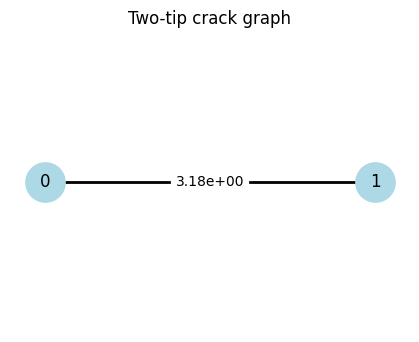

In [11]:
plt.figure(figsize=(4,3))

pos = {
    0: (tip_positions[0][0], tip_positions[0][1]),
    1: (tip_positions[1][0], tip_positions[1][1]),
}

nx.draw(
    G_graph,
    pos,
    with_labels=True,
    node_size=800,
    node_color="lightblue",
    edge_color="black",
    width=2,
)

edge_labels = {(0,1): f"{edge_weight:.2e}"}
nx.draw_networkx_edge_labels(G_graph, pos, edge_labels=edge_labels)

plt.title("Two-tip crack graph")
plt.axis("equal")
plt.show()


## Yay first graph!


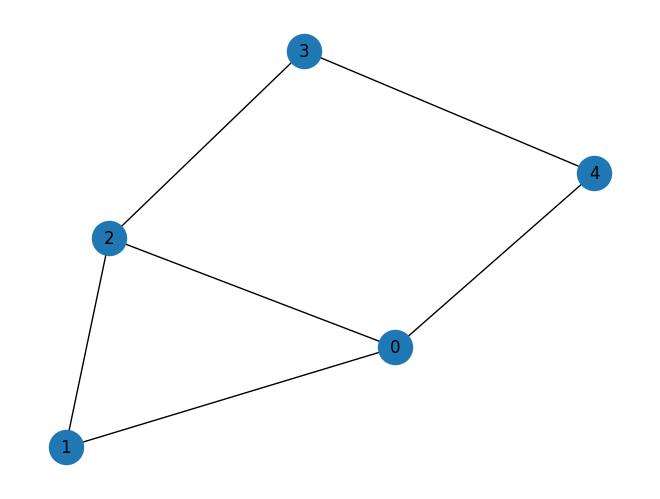

In [21]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from typing import List, Tuple
n = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [(0, 1, 1.0), (0, 2, 1.0), (0, 4, 1.0), (1, 2, 1.0), (2, 3, 1.0), (3, 4, 1.0)]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

## 3. Full Recho-style Hamiltonian for the isotropic two-tip crack

We now switch from the toy scalar Hamiltonian to the **full Recho
Hamiltonian structure**.

Recho's formulation works with a boundary state:

- $q$ – displacement vector on the contour (2D: normal and tangential components),
- $p$ – normalised traction vector on the contour.

He shows that these fields satisfy a first-order Hamiltonian system along
a contour parameter $t$ (which can be chosen as $\theta$, arc length,
or a related coordinate):

$$
\dot p = H_{22} p + H_{21} q, \qquad
\dot q = H_{12} p + H_{11} q,
$$

where the sub-blocks $H_{ij}$ are matrices constructed from the
material stiffness tensors via two intermediate matrices:

- $C_d$ – a positive-definite "dual capacitance" matrix,
- $C_f$ – another stiffness-like matrix.

In matrix form, with the state vector

$$
v =
\begin{bmatrix}
q \\ p
\end{bmatrix},
$$

we can write

$$
\dot v = H v,
\qquad
H =
\begin{bmatrix}
H_{11} & H_{12} \\
H_{21} & H_{22}
\end{bmatrix}.
$$

For crack-tip asymptotics in terms of the logarithmic radial coordinate
$\xi = \ln r$, we look for separated solutions

$$
v(\xi) = e^{(\lambda - 1)\xi} \Psi(\theta),
$$

which turns the system into an eigenvalue problem

$$
(\lambda - 1)\Psi = H \Psi.
$$

Thus, the eigenvalues of the Hamiltonian $H$ are related to the
singular exponents by

$$
\lambda_j = 1 + \mu_j, \quad
H\Psi_j = \mu_j \Psi_j.
$$

In the isotropic single-crack case we know analytically that
$\lambda = 1/2$ is one of the eigenvalues (corresponding to Modes I and II).
The goal of a full Recho implementation is to have the *numerical*
eigenvalues of $H$ reproduce $\lambda \approx 1/2$ in this benchmark case
and then generalise to more complex geometries and materials.


In [22]:
import numpy as np

# --- Isotropic stiffness in plane strain (Voigt notation) ---

lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))  # Lamé lambda
mu_iso = E / (2.0 * (1.0 + nu))                 # shear modulus (mu)

# Plane strain stiffness matrix C (3x3) in Voigt order [xx, yy, xy]
C_voigt = np.array([
    [lam + 2.0 * mu_iso, lam,               0.0],
    [lam,               lam + 2.0 * mu_iso, 0.0],
    [0.0,               0.0,                mu_iso],
])

C_voigt


array([[1.21153846e+10, 5.19230769e+09, 0.00000000e+00],
       [5.19230769e+09, 1.21153846e+10, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 3.46153846e+09]])